In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import get_window, spectrogram, lfilter, hilbert
from scipy.signal.windows import blackmanharris


In [ ]:
# =============================================================================
# SCRIPT PRINCIPAL
# =============================================================================
c = 3e8
# file = "../../data/kelly/A151P148R1S5D0.bin"
file = "../../data/antoine/radar9/test4.bin"


In [ ]:
radar_data = np.fromfile(file, dtype=np.uint16)

In [ ]:
print(radar_data)
print(len(radar_data))

[   0    1 9200 ... 1795 2022 1770]
5120006


In [ ]:
ch = radar_data[1]
print(ch)
frequ_start, frequ_stop = int(radar_data[2]*1e6), int(radar_data[3]*1e6)
print(frequ_start, frequ_stop)

1
9200000000 10200000000


In [ ]:
sweep_time = radar_data[4]/1e6
NTS = int(radar_data[5])
print(sweep_time, NTS)

0.004 1024


In [ ]:
raw_data = radar_data[6:]
len(raw_data)

5120000

In [ ]:
bw = frequ_stop - frequ_start
fc = frequ_start + bw/2

In [ ]:
# Dépaquetage I/Q selon le nombre de canaux
match ch :
    case 1:
        # nombre de chirps complets
        num_chirps = np.floor((len(raw_data) / 2) / NTS)

        samp_rate = NTS / sweep_time
        dopp_freq = 1 / sweep_time

        print(f"Fs: {samp_rate/1e3:.3f} kS/s | PRF: {dopp_freq:.2f} Hz | BW: {bw/1e6:.2f} MHz")

        ## nouveau chirp quand commence par HEADER
        HEADER = 49152

        idx = np.where(raw_data >= HEADER)[0]

        if len(idx) == 0:
            print("WARNING: Aucun header trouvé. Fichier ignoré.")
        else:
            
            start = idx[0]
            end = int(num_chirps * NTS * 2)

            # I/Q intercalés (pas de 2)
            I1 = raw_data[::2]
            Q1 = raw_data[1::2]

            # détection pertes
            header_index = np.where(I1 >= HEADER)[0]
            print(header_index)
            
            if np.any(np.diff(header_index) != NTS):
                print("ATTENTION: perte de données détectée.")

            # suppression header
            I1[header_index] = I1[header_index] - HEADER
            print(I1.shape)

            # centrage DC
            I1 = I1 - np.mean(I1)
            Q1 = Q1 - np.mean(Q1)

            data1 = I1 + 1j * Q1
            data1 = np.real(data1) + hilbert(np.real(data1))

    case 2:
        # Nombre de sweeps / chirps complets
        num_chirps = int(np.floor((len(raw_data) / 4) / NTS))

        samp_rate = NTS / sweep_time      # échantillons ADC / s
        dopp_freq = 1 / sweep_time        # PRF Doppler

        print(f"Fs: {samp_rate/1e3:.3f} kS/s | PRF: {dopp_freq:.2f} Hz | BW: {bw/1e6:.2f} MHz")

        HEADER = 49152

        idx = np.where(raw_data >= HEADER)[0]

        if len(idx) == 0:
            print("WARNING: Aucun header trouvé. Fichier ignoré.")
        else:
            
            start = idx[0]

            # Extraction I/Q intercalés
            I1 = raw_data[start : num_chirps*NTS*4-3 : 4]
            Q1 = raw_data[start+1 : num_chirps*NTS*4-2 : 4]
            I2 = raw_data[start+2 : num_chirps*NTS*4-1 : 4]
            Q2 = raw_data[start+3 : num_chirps*NTS*4   : 4]

            # Détection pertes données
            header_index = np.where(I1 >= HEADER)[0]

            if np.any(np.diff(header_index) != NTS):
                print("ATTENTION: perte de données détectée.")

            # Suppression tag header
            I1[header_index] = I1[header_index] - HEADER

            # Centrage DC
            I1 = I1 - np.mean(I1)
            Q1 = Q1 - np.mean(Q1)
            I2 = I2 - np.mean(I2)
            Q2 = Q2 - np.mean(Q2)

            data1 = I1 + 1j * Q1
            # data2 = I2 + 1j * Q2
    
    case _:
        print(f"Nombre de cannaux ch={ch} non géré")

Fs: 256.000 kS/s | PRF: 250.00 Hz | BW: 1000.00 MHz
[]
(2560000,)


In [ ]:
data1.shape

(2560000,)

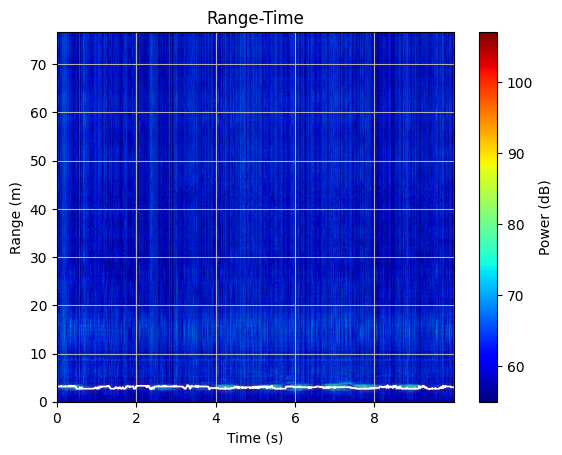

In [ ]:
# fs = fréquence d'échantillonnage ADC
fs = NTS / sweep_time

record_length = np.floor(len(data1) / NTS) * sweep_time
num_chirps = int(np.floor(record_length / sweep_time))

if num_chirps < 1:
    print("WARNING: Pas assez de données pour former au moins 1 chirp.")
else:

    # Tronquer pour multiple de NTS
    data1 = data1[:NTS * num_chirps]

    # matrice [samples x chirps]
    data_time = data1.reshape(NTS, num_chirps, order='F')

    # Fenêtre Blackman-Harris
    win = np.tile(blackmanharris(NTS), (num_chirps, 1)).T

    # Range FFT
    data_range = np.fft.fft(data_time * win, axis=0)

    # garder demi bande positive
    data_range = data_range[:NTS//2, :]

    # =========================
    # MTI filter (5-pulse canceler)
    # =========================
    filterCoeffs = np.array([1, 3, -2, -3, 1])

    data_range_MTI = lfilter(filterCoeffs, 1, data_range, axis=1)

    # =========================
    # Axes temps et distance
    # =========================
    ns = data_range_MTI.shape[1]        # Nn de chprs pour l'échelle temps

    time_axis = np.arange(ns) * sweep_time

    k = np.arange(0, NTS//2)
    freq_axis = k * (fs / NTS)

    c = 3e8
    range_axis = (freq_axis * c * sweep_time) / (2 * bw)

    # =========================
    # Range-Time plot
    # =========================
    plt.figure("Range-Time")

    plt.imshow(
        20*np.log10(np.abs(data_range_MTI)),
        aspect='auto',
        extent=[time_axis[0], time_axis[-1], range_axis[0], range_axis[-1]],
        origin='lower',
        cmap='jet',
        vmin=55,
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Range (m)")
    plt.title("Range-Time")

    plt.colorbar(label="Power (dB)")
    plt.grid(True)

    # CFAR + piste + overlay
    MIN_RANGE_FOR_DOPPLER_DETECTION = 2
    MAX_RANGE_FOR_DOPPLER_DETECTION = 5

    dt_for_mask = sweep_time
    vmax = 2.0

    M, W, rhat, Thr, B = build_mask_cfar_dp(
        data_range_MTI,
        range_axis,
        dt_for_mask,
        vmax,
        MinRange=MIN_RANGE_FOR_DOPPLER_DETECTION,
        MaxRange=MAX_RANGE_FOR_DOPPLER_DETECTION,
        Mode='SOCA',
        Train=8,
        Guard=2,
        Pfa=1e-3,
        BandHalfWidth=0.8,
        SoftSigma=0.8,
        SoftFloor=0.05
    )

    plt.imshow(
        M.astype(float),
        aspect='auto',
        origin='lower',
        extent=[time_axis.min(), time_axis.max(),
                range_axis.min(), range_axis.max()],
        cmap='jet',
        alpha=0.25
    )

    rhat_idx = np.array(rhat, dtype=float)
    rhat_idx[np.isnan(rhat_idx)] = 0
    rhat_idx = rhat_idx.astype(int)

    plt.plot(
        time_axis,
        range_axis[rhat_idx],
        'w-',
        linewidth=1.2
    )

    # plt.ylim(MIN_RANGE_FOR_DOPPLER_DETECTION, 5)

    plt.show()


In [ ]:
# === sélection des bins de distance ===

bin_indl = np.where(range_axis >= MIN_RANGE_FOR_DOPPLER_DETECTION)[0][0]
bin_indu = np.where(range_axis <= MAX_RANGE_FOR_DOPPLER_DETECTION)[0][-1]


# === paramètres Doppler ===

MD = {}

MD["PRF"] = 1 / sweep_time
MD["TimeWindowLength"] = 256
MD["OverlapFactor"] = 0.95
MD["OverlapLength"] = round(MD["TimeWindowLength"] * MD["OverlapFactor"])

MD["Pad_Factor"] = 4
MD["FFTPoints"] = MD["Pad_Factor"] * MD["TimeWindowLength"]

MD["DopplerBin"] = MD["PRF"] / MD["FFTPoints"]

MD["DopplerAxis"] = np.arange(
    -MD["PRF"]/2,
    MD["PRF"]/2,
    MD["DopplerBin"]
)

MD["WholeDuration"] = data_range_MTI.shape[1] / MD["PRF"]


# === paramètres STFT ===

N_SFFT_points = 256
Pad_Factor = 4
OverlapFactor = 0.95

window2 = get_window('hann', N_SFFT_points)

use_soft_mask = True

# === sélection des lignes (bins distance) ===

rows = np.arange(bin_indl, bin_indu + 1)

if "M" in locals() and M is not None:
    active = np.any(M[rows, :], axis=1)
    rows = rows[active]

    if len(rows) == 0:
        rows = np.arange(bin_indl, bin_indu + 1)


# === calcul spectrogramme Doppler ===

data_spec_MTI2 = 0

for RBin in rows:

    if use_soft_mask:
        x = data_range_MTI[RBin, :] * W[RBin, :]
    else:
        x = data_range_MTI[RBin, :].copy()
        x[~M[RBin, :]] = 0

    f, t, S = spectrogram(
        x,
        window=window2,
        noverlap=int(OverlapFactor * N_SFFT_points),
        nfft=Pad_Factor * N_SFFT_points,
        mode="magnitude"
    )

    S = np.fft.fftshift(S, axes=0)

    data_spec_MTI2 += np.abs(S)


# === axe temps ===

MD["TimeAxis"] = np.linspace(
    0,
    MD["WholeDuration"],
    data_spec_MTI2.shape[1]
)


# === inversion + normalisation ===

data_spec_MTI2 = np.flipud(data_spec_MTI2)

MaxVal = np.max(data_spec_MTI2)
MinVal = np.min(data_spec_MTI2)

if MaxVal > MinVal:
    data_spec_MTI2 = (data_spec_MTI2 - MinVal) / (MaxVal - MinVal)


# === conversion Doppler → vitesse ===

vel_axis = MD["DopplerAxis"] * c / (2 * fc)

C:\Users\Kelly\AppData\Local\Temp\ipykernel_10740\3854942923.py:64: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, S = spectrogram(


C:\Users\Kelly\AppData\Local\Temp\ipykernel_10740\192205300.py:4: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(np.abs(data_spec_MTI2)),


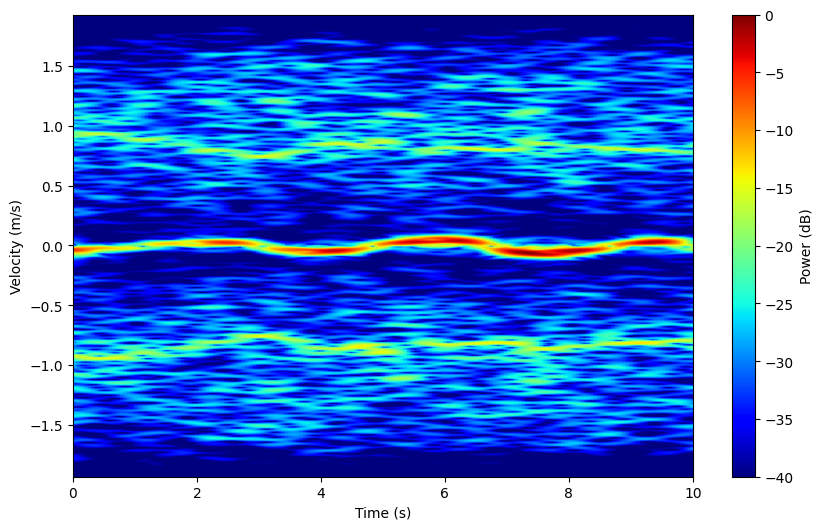

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

im = ax.imshow(
    20*np.log10(np.abs(data_spec_MTI2)),
    aspect='auto',
    origin='lower',
    extent=[MD["TimeAxis"][0], MD["TimeAxis"][-1],
            vel_axis[0], vel_axis[-1]],
    cmap='jet',
    vmin=-40,
    vmax=0
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Power (dB)")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

plt.show()

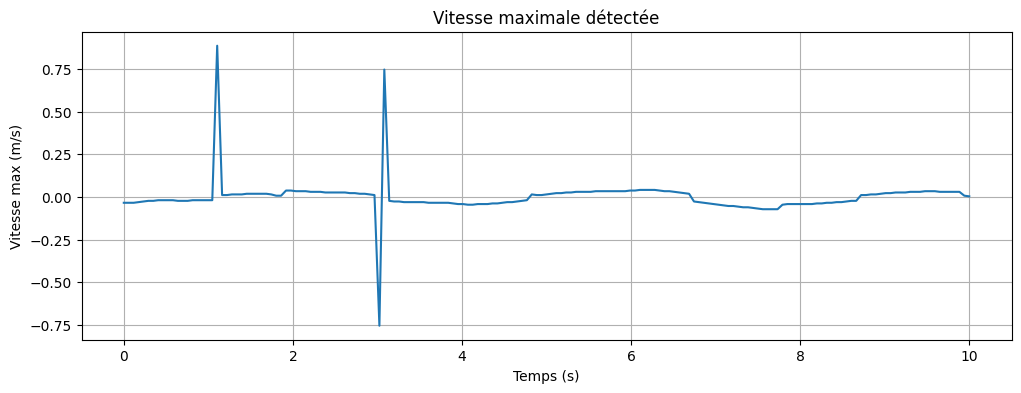

In [ ]:
# ============================================
# Vitesse max détectée pour chaque bin temporel STFT
# ============================================

num_time_bins = data_spec_MTI2.shape[1]
vmax_time = np.zeros(num_time_bins)

for k in range(num_time_bins):
    idx_max = np.argmax(data_spec_MTI2[:, k])  # index Doppler max
    vmax_time[k] = vel_axis[idx_max]           # vitesse correspondante

# Créer un DataFrame et sauvegarder en CSV
df = pd.DataFrame({
    "Time_s": MD["TimeAxis"],
    "Vmax_m_s": vmax_time
})

# df.to_csv("./Y_vitesse.csv", index=False)
df.to_csv("./test4.csv", index=False)

# Tracer la vitesse maximale détectée
plt.figure(figsize=(12,4))
plt.plot(MD["TimeAxis"], vmax_time, linewidth=1.5)
plt.grid(True)
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse max (m/s)")
plt.title("Vitesse maximale détectée")
plt.show()